#### Data Set

In [ ]:
import pandas as pd
import random

data = []

for i in range(100):

    study_hours = random.randint(5, 30)
    attendance = random.randint(50, 100)
    group_discussion = random.choice(["Yes", "No"])
    previous_test_score = random.randint(30, 100)
    final_exam_pass = random.choice(["Pass", "Fail"])

    data.append([
        study_hours,
        attendance,
        group_discussion,
        previous_test_score,
        final_exam_pass
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "study_hours",
    "attendance",
    "group_discussion",
    "previous_test_score",
    "final_exam_pass"
])

# Display data
print(df)

# Save as CSV
df.to_csv("student_data.csv", index=False)

print("CSV file created successfully!")

    study_hours  attendance group_discussion  previous_test_score  \
0            29          92               No                   56   
1            15          85               No                   72   
2            22          51              Yes                   96   
3            15          62               No                   78   
4            27          78               No                   67   
..          ...         ...              ...                  ...   
95           25          70               No                   71   
96            7          52              Yes                   84   
97            7          96               No                  100   
98           10          70              Yes                   65   
99           24          52              Yes                   62   

   final_exam_pass  
0             Fail  
1             Pass  
2             Fail  
3             Fail  
4             Fail  
..             ...  
95            Pass  
96 

# 1. Understanding the Basics

Explain in your own words:
- What is Probability?
- What are Key Probability Terminology?
- Give at least three probability event examples from the dataset.### Probability Definition

Probability measures the likelihood of an event occurring. It ranges from 0 (impossible) to 1 (certain).

### Key Terminology

* **Experiment:** A process that leads to an outcome.
* **Outcome:** The result of a single trial of an experiment.
* **Sample Space:** The set of all possible outcomes.
* **Event:** One or more outcomes of an experiment.

### Examples from Dataset

1. Probability of a student passing (final_exam_pass == "Pass").
2. Probability that a student participates in group discussions (group_discussion == "Yes").
3. Probability that previous test score was above 80.

## 2. Types of Events

* Identify one **empirical probability** and one **theoretical probability** scenario from the dataset and Calculate both.

In [4]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv("student_data.csv")

    # Empirical probability from the observed dataset
    total_students = len(df)
    failed_students = (df["final_exam_pass"] == "Fail").sum()
    empirical_probability = failed_students / total_students if total_students else 0

    print(
        f"Empirical probability of failing: "
        f"{failed_students}/{total_students} = {empirical_probability:.2%}"
    )

    # Theoretical probability assuming Pass and Fail are equally likely
    theoretical_probability = 1 / 2
    print(
        f"Theoretical probability of failing: "
        f"1/2 = {theoretical_probability:.2%}"
    )

except FileNotFoundError:
    print("Error: 'student_data.csv' was not found.")
except KeyError:
    print("Error: The dataset must contain a 'final_exam_pass' column.")

Empirical probability of failing: 51/100 = 51.00%
Theoretical probability of failing: 1/2 = 50.00%


### 3. Random Variable & Probability Distribution

    Define a random variable for the event "Number of students passing the final scenario" out of 3 randomly selected students.
    Find the mean and variance of this random variable.

In [12]:
import math
import pandas as pd

students = pd.read_csv("student_data.csv")
probability_pass = (students["final_exam_pass"] == "Pass").mean()

# X is the number of students who pass out of 3 selected students.
sample_size = 3
probability_distribution = {
    passes: math.comb(sample_size, passes)
    * probability_pass**passes
    * (1 - probability_pass) ** (sample_size - passes)
    for passes in range(sample_size + 1)
}

mean = sample_size * probability_pass
variance = sample_size * probability_pass * (1 - probability_pass)

print(f"Estimated probability of passing: {probability_pass:.4f}")
print("Probability distribution:")
for passes, probability in probability_distribution.items():
    print(f"P(X={passes}) = {probability:.4f}")
print(f"Mean E[X]: {mean:.4f}")
print(f"Variance Var(X): {variance:.4f}")

Estimated probability of passing: 0.4900
Probability distribution:
P(X=0) = 0.1327
P(X=1) = 0.3823
P(X=2) = 0.3674
P(X=3) = 0.1176
Mean E[X]: 1.4700
Variance Var(X): 0.7497



### 4. Venn Diagram in Probability
   - Draw a Venn diagram showing:
     - Students who study more than 10 hours/week.
     - Students who attend more than 80% of classes.
     - Overlap showing students who satisfy both conditions.


Matplotlib is building the font cache; this may take a moment.


Study > 10 hours only: 44
Attendance > 80% only: 9
Both conditions: 32
Neither condition: 15


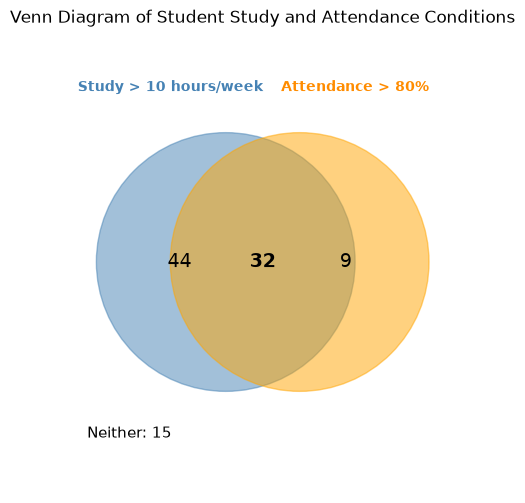

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

students = pd.read_csv("student_data.csv")

study_more_than_10 = students["study_hours"] > 10
attendance_more_than_80 = students["attendance"] > 80

study_only = (study_more_than_10 & ~attendance_more_than_80).sum()
attendance_only = (~study_more_than_10 & attendance_more_than_80).sum()
both_conditions = (study_more_than_10 & attendance_more_than_80).sum()
neither_condition = (~study_more_than_10 & ~attendance_more_than_80).sum()

print(f"Study > 10 hours only: {study_only}")
print(f"Attendance > 80% only: {attendance_only}")
print(f"Both conditions: {both_conditions}")
print(f"Neither condition: {neither_condition}")

fig, axis = plt.subplots(figsize=(8, 6))
axis.add_patch(Circle((0.42, 0.5), 0.28, color="steelblue", alpha=0.5))
axis.add_patch(Circle((0.58, 0.5), 0.28, color="orange", alpha=0.5))

axis.text(0.32, 0.5, str(study_only), ha="center", va="center", fontsize=14)
axis.text(0.68, 0.5, str(attendance_only), ha="center", va="center", fontsize=14)
axis.text(0.50, 0.5, str(both_conditions), ha="center", va="center", fontsize=14, fontweight="bold")
axis.text(0.12, 0.12, f"Neither: {neither_condition}", fontsize=11)

axis.text(0.30, 0.87, "Study > 10 hours/week", ha="center", color="steelblue", fontweight="bold")
axis.text(0.70, 0.87, "Attendance > 80%", ha="center", color="darkorange", fontweight="bold")
axis.set_title("Venn Diagram of Student Study and Attendance Conditions")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.set_aspect("equal")
axis.axis("off")
plt.show()


### 5. Contingency Table & Probability Calculations
   - Create a contingency table for group_discussion (Yes/No) vs. final_exam_pass (Pass/Fail).
   - From the table, calculate:
     - Joint probability of "Participates in group discussion AND Passes exam".
     - Marginal probability of "Passes exam".
     - Conditional probability of "Passes exam given participation in group discussion".


In [17]:
import pandas as pd

# Load the data
students = pd.read_csv("student_data.csv")

# Create the contingency table
contingency_table = pd.crosstab(
    students["group_discussion"],
    students["final_exam_pass"]
)
print(contingency_table)

# Total number of students
total_students = len(students)

# Joint probability: group discussion = Yes AND exam result = Pass
joint_count = len(students[
    (students["group_discussion"] == "Yes") &
    (students["final_exam_pass"] == "Pass")
])
joint_probability = joint_count / total_students

# Marginal probability: exam result = Pass
pass_count = len(students[students["final_exam_pass"] == "Pass"])
pass_probability = pass_count / total_students

# Conditional probability: Pass given group discussion = Yes
discussion_count = len(students[students["group_discussion"] == "Yes"])
conditional_probability = joint_count / discussion_count

print("Joint probability (Discussion and Pass):", joint_probability)
print("Marginal probability (Pass):", pass_probability)
print("Conditional probability (Pass given Discussion):", conditional_probability)

final_exam_pass   Fail  Pass
group_discussion            
No                  28    23
Yes                 23    26
Joint probability (Discussion and Pass): 0.26
Marginal probability (Pass): 0.49
Conditional probability (Pass given Discussion): 0.5306122448979592


### 6. Understanding Relationships
* Interpret conditional probability results in plain language ("intuition" behind formula).
* Identify if "participating in group discussions" and "passing exam" are independent, dependent, or mutually exclusive events. Justify your answer.


In [19]:
import pandas as pd

students = pd.read_csv("student_data.csv")

# Probability of passing for all students
pass_count = len(students[students["final_exam_pass"] == "Pass"])
total_students = len(students)
probability_pass = pass_count / total_students

# Probability of passing after joining a discussion
discussion_students = students[students["group_discussion"] == "Yes"]
discussion_pass_count = len(
    discussion_students[discussion_students["final_exam_pass"] == "Pass"]
)
probability_pass_given_discussion = discussion_pass_count / len(discussion_students)

print("Probability of passing:", round(probability_pass, 2))
print("Probability of passing given discussion:", round(probability_pass_given_discussion, 2))
print()
print("Interpretation:")
print("Overall, 49% of students passed the exam.")
print("Among discussion participants, about 53% passed.")
print("Knowing that a student joined a discussion changes the probability.")

if probability_pass_given_discussion == probability_pass:
    print("The events are independent.")
else:
    print("The events are dependent because the probabilities are different.")

if discussion_pass_count == 0:
    print("The events are mutually exclusive.")
else:
    print("The events are not mutually exclusive because some students did both.")

print()
print("Intuition: conditional probability asks how likely passing is after we know the student joined a discussion.")

Probability of passing: 0.49
Probability of passing given discussion: 0.53

Interpretation:
Overall, 49% of students passed the exam.
Among discussion participants, about 53% passed.
Knowing that a student joined a discussion changes the probability.
The events are dependent because the probabilities are different.
The events are not mutually exclusive because some students did both.

Intuition: conditional probability asks how likely passing is after we know the student joined a discussion.


### 7. Bayes Theorem Application

*   **Scenario:** Suppose historical data shows:
    *   70% of students who pass had high attendance (>80%).
    *   40% of students who fail also had high attendance.
    *   60% of all students had high attendance.
    *   **Question:** Use Bayes Theorem to find the probability that a student passed the exam given they had high attendance.

In [20]:
# Given probabilities
probability_high_given_pass = 0.70
probability_high_given_fail = 0.40
probability_high = 0.60

# First find P(Pass):
# P(High) = P(High|Pass)P(Pass) + P(High|Fail)P(Fail)
# Since P(Fail) = 1 - P(Pass):
probability_pass = (
    probability_high - probability_high_given_fail
) / (probability_high_given_pass - probability_high_given_fail)

# Bayes Theorem:
# P(Pass|High) = P(High|Pass)P(Pass) / P(High)
probability_pass_given_high = (
    probability_high_given_pass * probability_pass
) / probability_high

print("Probability of passing:", round(probability_pass, 4))
print("Probability of passing given high attendance:", round(probability_pass_given_high, 4))
print("As a percentage:", round(probability_pass_given_high * 100, 2), "%")

Probability of passing: 0.6667
Probability of passing given high attendance: 0.7778
As a percentage: 77.78 %
